In [1]:
import pandas as pd
import numpy as np


data = pd.read_csv("/home/patel-krish/Documents/Clustering Cardiac arrest.txt")


print(data.head())


print("Null values in dataset:")
print(data.isnull().sum())


print("Dataset Information:")
print(data.info())


print("Statistical Description:")
print(data.describe())


X = data.drop("UnderRisk", axis=1)

print("Dataset after dropping UnderRisk column:")
print(X.head())

   Gender  Chain_smoker  Consumes_other_tobacco_products  HighBP  Obese  \
0       1             1                                1       0      1   
1       1             0                                1       0      1   
2       1             0                                1       0      1   
3       1             0                                1       0      1   
4       1             0                                0       0      0   

   Diabetes  Metabolic_syndrome  Use_of_stimulant_drugs  Family_history  \
0         0                   0                       0               1   
1         0                   0                       0               1   
2         0                   0                       0               1   
3         0                   0                       0               1   
4         0                   1                       1               0   

   History_of_preeclampsia  CABG_history  Respiratory_illness UnderRisk  
0                       

In [13]:
from sklearn.cluster import KMeans

# choose number of clusters
kmeans = KMeans(n_clusters=6, random_state=42)

# fit model
kmeans.fit(X)

KMeans(n_clusters=6, random_state=42)

In [3]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[ 1.02702703e+00  1.08108108e-01  2.16216216e-01  2.70270270e-02
  -4.44089210e-16  8.10810811e-02  1.00000000e+00  1.00000000e+00
   8.10810811e-02 -1.04083409e-17 -1.04083409e-17 -1.38777878e-17]
 [ 2.00000000e+00  5.97609562e-02  9.16334661e-01  6.37450199e-02
   9.48207171e-01  2.78884462e-02 -4.16333634e-17  5.57768924e-02
   9.52191235e-01  4.85722573e-17  7.96812749e-03  3.98406375e-02]
 [ 9.63394343e-01  1.46422629e-01  8.43594010e-01  9.98336106e-02
   9.63394343e-01  6.48918469e-02  1.66389351e-03  3.66056572e-02
   9.66722130e-01  2.66222962e-02  2.82861897e-02  3.16139767e-02]]


In [4]:
data["cluster"] = kmeans.labels_

print(data.head())

   Gender  Chain_smoker  Consumes_other_tobacco_products  HighBP  Obese  \
0       1             1                                1       0      1   
1       1             0                                1       0      1   
2       1             0                                1       0      1   
3       1             0                                1       0      1   
4       1             0                                0       0      0   

   Diabetes  Metabolic_syndrome  Use_of_stimulant_drugs  Family_history  \
0         0                   0                       0               1   
1         0                   0                       0               1   
2         0                   0                       0               1   
3         0                   0                       0               1   
4         0                   1                       1               0   

   History_of_preeclampsia  CABG_history  Respiratory_illness UnderRisk  \
0                      

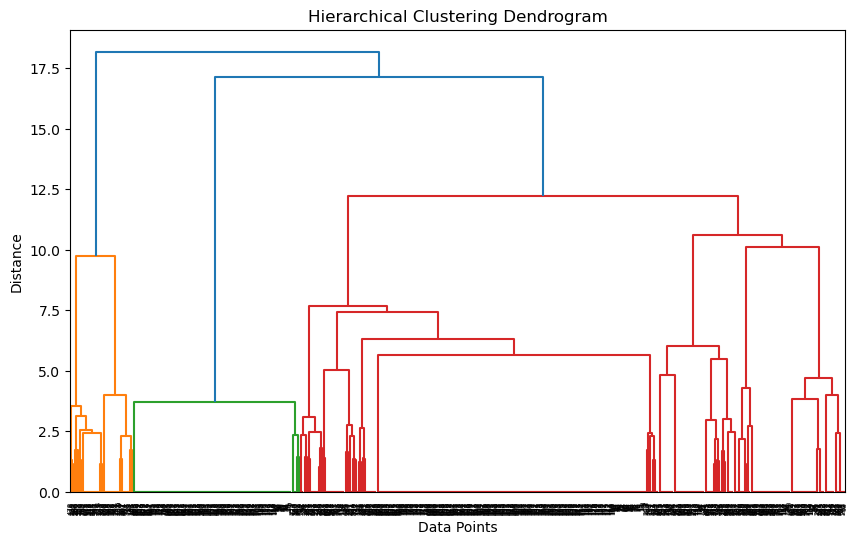

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [40]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=80)

labels = agg.fit_predict(X)

In [7]:
data["label"] = labels

print(data.head())

   Gender  Chain_smoker  Consumes_other_tobacco_products  HighBP  Obese  \
0       1             1                                1       0      1   
1       1             0                                1       0      1   
2       1             0                                1       0      1   
3       1             0                                1       0      1   
4       1             0                                0       0      0   

   Diabetes  Metabolic_syndrome  Use_of_stimulant_drugs  Family_history  \
0         0                   0                       0               1   
1         0                   0                       0               1   
2         0                   0                       0               1   
3         0                   0                       0               1   
4         0                   1                       1               0   

   History_of_preeclampsia  CABG_history  Respiratory_illness UnderRisk  \
0                      

In [8]:
print("Cluster Label Counts:")
print(data["label"].value_counts())

Cluster Label Counts:
label
0    626
2    191
1     72
Name: count, dtype: int64


In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.9583802024746907
